# Salary Prediction — Data Cleaning & Feature Engineering

This dataset is already clean (no missing values, no duplicates). Cleaning is therefore a no-op; we only do feature engineering:

1. Add `exp_squared` and `exp_log` to allow non-linear shapes
2. Add `experience_band` (entry / mid / senior) for tree models
3. One-hot encode the band
4. Save to `data/salary_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import load_data, create_features, preprocess_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/salary.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 2. Missing / Invalid Values

In [3]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values: 0
Duplicate rows: 0


## 3. Distribution Check Before Engineering

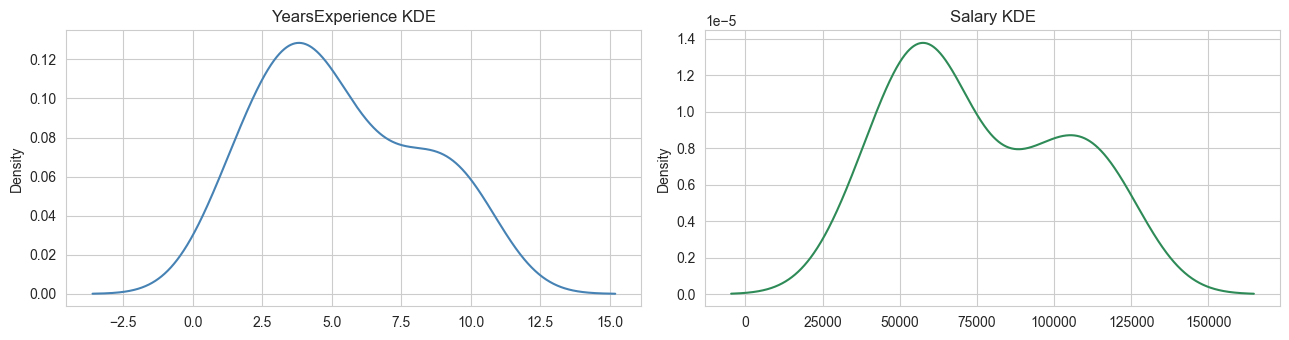

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
df["YearsExperience"].plot(kind="kde", ax=axes[0], color="steelblue")
axes[0].set_title("YearsExperience KDE")
df["Salary"].plot(kind="kde", ax=axes[1], color="seagreen")
axes[1].set_title("Salary KDE")
plt.tight_layout(); plt.show()

## 4. Feature Engineering

In [5]:
df_feat = create_features(df)
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"New features: {new_cols}")
df_feat.head()

New features: ['exp_squared', 'exp_log', 'experience_band']


,YearsExperience,Salary,exp_squared,exp_log,experience_band
0,1.1,39343.0,1.21,0.741937,entry
1,1.3,46205.0,1.69,0.832909,entry
2,1.5,37731.0,2.25,0.916291,entry
3,2.0,43525.0,4.00,1.098612,entry
4,2.2,39891.0,4.84,1.163151,entry


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_59854/2934020062.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="experience_band", y="Salary", data=df_feat, palette="Set2",


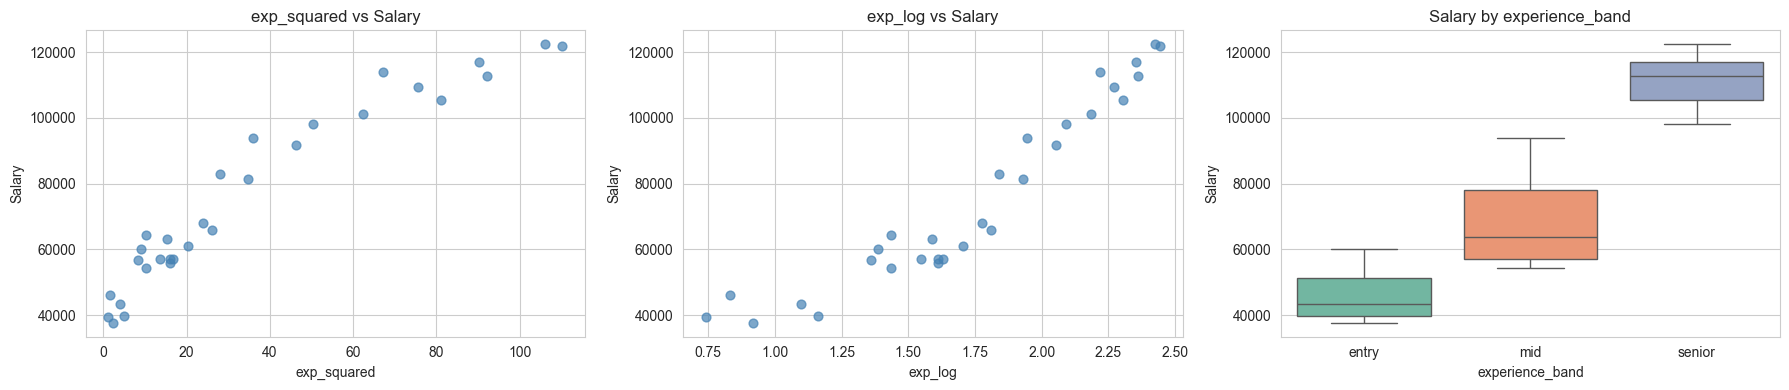

In [6]:
# Visualize transforms vs Salary
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(df_feat["exp_squared"], df_feat["Salary"], alpha=0.7, color="steelblue", s=40)
axes[0].set_xlabel("exp_squared"); axes[0].set_ylabel("Salary"); axes[0].set_title("exp_squared vs Salary")

axes[1].scatter(df_feat["exp_log"], df_feat["Salary"], alpha=0.7, color="steelblue", s=40)
axes[1].set_xlabel("exp_log"); axes[1].set_ylabel("Salary"); axes[1].set_title("exp_log vs Salary")

sns.boxplot(x="experience_band", y="Salary", data=df_feat, palette="Set2",
            order=["entry","mid","senior"], ax=axes[2])
axes[2].set_title("Salary by experience_band")
plt.tight_layout(); plt.show()

## 5. Run the Full Pipeline

In [7]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (30, 6)
Missing values : 0


,YearsExperience,Salary,exp_squared,exp_log,experience_band_mid,experience_band_senior
0,1.1,39343.0,1.21,0.741937,0,0
1,1.3,46205.0,1.69,0.832909,0,0
2,1.5,37731.0,2.25,0.916291,0,0
3,2.0,43525.0,4.00,1.098612,0,0
4,2.2,39891.0,4.84,1.163151,0,0


## 6. Sanity Checks & Save

In [8]:
assert df_processed.isnull().sum().sum() == 0
assert "Salary" in df_processed.columns
print("All checks passed.")

All checks passed.


In [9]:
df_processed.to_csv("data/salary_cleaned.csv", index=False)
print(f"Saved data/salary_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/salary_cleaned.csv (30 rows, 6 cols)
